In [ ]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
DATA_PATH = "data/sales_data.csv"
MODEL_PATH ="model.joblib"
SCALER_PATH = "scaler.joblib"

In [74]:
def load_data(filepath):
    """Load CSV data"""
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File not found: {filepath}")
    df = pd.read_csv(filepath)
    return df

df = load_data(DATA_PATH)
df.head()

,product_id,product_name,jumlah_penjualan,harga,diskon,status
0,P00001,Produk 1,57,26556,25,Tidak
1,P00002,Produk 2,140,84196,5,Laris
2,P00003,Produk 3,71,46868,25,Tidak
3,P00004,Produk 4,279,42790,20,Laris
4,P00005,Produk 5,216,28331,0,Laris


In [68]:
def explore_data(df):
    """Explore data characteristics"""
    print("DATA EXPLORATION")
    print("="*60)

    print("\nDataset Info:")
    print(f"Shape: {df.shape}")
    print(f"\nColumns:\n{df.dtypes}")

    print(f"\nMissing Values:\n{df.isnull().sum()}")

    print(f"\nDescriptive Statistics:\n{df.describe()}")

    print(f"\nTarget Distribution:")
    status_counts = df['status'].value_counts()
    print(f"\n{status_counts}")
    print(f"Percentage:\n{(status_counts / len(df) * 100).round(2)}")

    # Check for duplicate values
    duplicates = df.duplicated().sum()
    print(f"\nDuplicate rows: {duplicates}")

    return df.describe()

explore_data(df)

DATA EXPLORATION

Dataset Info:
Shape: (5000, 6)

Columns:
product_id          object
product_name        object
jumlah_penjualan     int64
harga                int64
diskon               int64
status              object
dtype: object

Missing Values:
product_id          0
product_name        0
jumlah_penjualan    0
harga               0
diskon              0
status              0
dtype: int64

Descriptive Statistics:
       jumlah_penjualan          harga       diskon
count       5000.000000    5000.000000  5000.000000
mean         150.052000  110792.249800    14.774000
std           86.837583   51792.314449     9.948302
min            0.000000   20044.000000     0.000000
25%           74.000000   66053.250000     5.000000
50%          152.000000  111320.000000    15.000000
75%          225.000000  155962.250000    25.000000
max          300.000000  199991.000000    30.000000

Target Distribution:

status
Laris    3608
Tidak    1392
Name: count, dtype: int64
Percentage:
status
Laris  

,jumlah_penjualan,harga,diskon
count,5000.000000,5000.000000,5000.000000
mean,150.052000,110792.249800,14.774000
std,86.837583,51792.314449,9.948302
min,0.000000,20044.000000,0.000000
25%,74.000000,66053.250000,5.000000
50%,152.000000,111320.000000,15.000000
75%,225.000000,155962.250000,25.000000
max,300.000000,199991.000000,30.000000


In [69]:
def preprocess_data(df):
    df_clean = df.copy()

    if df_clean.isnull().sum().sum() > 0:
        # Drop rows dengan missing values (simple approach)
        df_clean = df_clean.dropna()
        print(f"✓ Rows after dropping NaN: {len(df_clean)}")
    else:
        print("✓ No missing values found")

    # Ensure numeric columns are numeric
    numeric_cols = ['jumlah_penjualan', 'harga', 'diskon']
    for col in numeric_cols:
        try:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        except:
            print(f"Could not convert {col} to numeric")

    # Remove rows dengan negative values (invalid)
    before_len = len(df_clean)
    df_clean = df_clean[
        (df_clean['jumlah_penjualan'] >= 0) &
        (df_clean['harga'] >= 0) &
        (df_clean['diskon'] >= 0) &
        (df_clean['diskon'] <= 100)
    ]
    removed = before_len - len(df_clean)

    if removed > 0:
        print(f"✓ Removed {removed} rows dengan invalid values")
    else:
        print("✓ No invalid values found")

    # ===== ENCODE TARGET VARIABLE =====
    print("\nEncoding target variable...")
    status_mapping = {'Laris': 1, 'Tidak': 0}

    if 'status' not in df_clean.columns:
        raise ValueError("'status' column not found in data")

    # Validate status values
    valid_statuses = df_clean['status'].unique()
    print(f"Unique status values: {valid_statuses}")

    df_clean['status_encoded'] = df_clean['status'].map(status_mapping)

    if df_clean['status_encoded'].isnull().sum() > 0:
        df_clean = df_clean.dropna(subset=['status_encoded'])

    print(f"✓ Status encoded: Laris=1, Tidak Laris=0")

    # ===== SEPARATE FEATURES AND TARGET =====
    print("\nSeparating features and target...")

    X = df_clean[['jumlah_penjualan', 'harga', 'diskon']].values
    y = df_clean['status_encoded'].values

    print(f"✓ Features shape: {X.shape}")
    print(f"✓ Target shape: {y.shape}")
    print(f"✓ Class distribution: {np.bincount(y.astype(int))}")

    return X, y, df_clean

X, y, df_clean = preprocess_data(df)

✓ No missing values found
✓ No invalid values found

Encoding target variable...
Unique status values: ['Tidak' 'Laris']
✓ Status encoded: Laris=1, Tidak Laris=0

Separating features and target...
✓ Features shape: (5000, 3)
✓ Target shape: (5000,)
✓ Class distribution: [1392 3608]


In [70]:
def prepare_features(X, y, test_size=0.2, random_state=42):
    """Split data dan scale features"""

    # Split data
    print(f"\nSplitting data (test_size={test_size})...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    print(f"✓ Training set: {X_train.shape[0]} samples")
    print(f"✓ Test set: {X_test.shape[0]} samples")
    print(f"✓ Train class distribution: {np.bincount(y_train.astype(int))}")
    print(f"✓ Test class distribution: {np.bincount(y_test.astype(int))}")

    # Scale features
    print(f"\nScaling features dengan StandardScaler...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"✓ Features scaled")
    print(f"✓ Train mean: {X_train_scaled.mean(axis=0)}")
    print(f"✓ Train std: {X_train_scaled.std(axis=0)}")

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

X_train, X_test, y_train, y_test, scaler = prepare_features(X, y)


Splitting data (test_size=0.2)...
✓ Training set: 4000 samples
✓ Test set: 1000 samples
✓ Train class distribution: [1114 2886]
✓ Test class distribution: [278 722]

Scaling features dengan StandardScaler...
✓ Features scaled
✓ Train mean: [-2.12690976e-16 -3.77475828e-17  9.60218016e-16]
✓ Train std: [1. 1. 1.]


In [71]:
def train_model(X_train, y_train, random_state=42):
    """Train Random Forest classifier"""

    print("\nTraining Random Forest Classifier...")
    print("Hyperparameters:")
    print("  - n_estimators: 100")
    print("  - max_depth: 10")
    print("  - min_samples_split: 5")
    print("  - min_samples_leaf: 2")
    print("  - random_state: 42")

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=random_state,
        n_jobs=-1,
        verbose=0
    )

    model.fit(X_train, y_train)
    print("✓ Model training completed")

    return model

# Train model
model = train_model(X_train, y_train)


Training Random Forest Classifier...
Hyperparameters:
  - n_estimators: 100
  - max_depth: 10
  - min_samples_split: 5
  - min_samples_leaf: 2
  - random_state: 42
✓ Model training completed


In [72]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    """Evaluate model performance"""
    print("\n" + "="*60)
    print("MODEL EVALUATION")
    print("="*60)

    # Training predictions
    print("\nTraining Set Performance:")
    y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)

    print(f"  Accuracy:  {train_accuracy:.4f}")
    print(f"  Precision: {train_precision:.4f}")
    print(f"  Recall:    {train_recall:.4f}")
    print(f"  F1-Score:  {train_f1:.4f}")

    # Test predictions
    print("\nTest Set Performance:")
    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    print(f"  Accuracy:  {test_accuracy:.4f}")
    print(f"  Precision: {test_precision:.4f}")
    print(f"  Recall:    {test_recall:.4f}")
    print(f"  F1-Score:  {test_f1:.4f}")

    # Confusion Matrix
    print("\nConfusion Matrix (Test Set):")
    cm = confusion_matrix(y_test, y_test_pred)
    print(f"  True Negatives:  {cm[0, 0]} (Tidak Laris correctly predicted)")
    print(f"  False Positives: {cm[0, 1]} (Tidak Laris wrongly predicted as Laris)")
    print(f"  False Negatives: {cm[1, 0]} (Laris wrongly predicted as Tidak Laris)")
    print(f"  True Positives:  {cm[1, 1]} (Laris correctly predicted)")

    # Classification Report
    print("\nClassification Report (Test Set):")
    report = classification_report(
        y_test, y_test_pred,
        target_names=['Tidak', 'Laris'],
        digits=4
    )
    print(f"\n{report}")

    # Feature Importance
    print("\nFeature Importance:")
    feature_names = ['jumlah_penjualan', 'harga', 'diskon']
    importances = model.feature_importances_
    for name, importance in zip(feature_names, importances):
        print(f"  {name}: {importance:.4f}")

    return {
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'confusion_matrix': cm,
        'classification_report': report
    }

# Evaluate model
metrics = evaluate_model(model, X_train, X_test, y_train, y_test)


MODEL EVALUATION

Training Set Performance:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

Test Set Performance:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

Confusion Matrix (Test Set):
  True Negatives:  278 (Tidak Laris correctly predicted)
  False Positives: 0 (Tidak Laris wrongly predicted as Laris)
  False Negatives: 0 (Laris wrongly predicted as Tidak Laris)
  True Positives:  722 (Laris correctly predicted)

Classification Report (Test Set):

              precision    recall  f1-score   support

       Tidak     1.0000    1.0000    1.0000       278
       Laris     1.0000    1.0000    1.0000       722

    accuracy                         1.0000      1000
   macro avg     1.0000    1.0000    1.0000      1000
weighted avg     1.0000    1.0000    1.0000      1000


Feature Importance:
  jumlah_penjualan: 0.9891
  harga: 0.0090
  diskon: 0.0019



CONFUSION MATRIX VISUALIZATION


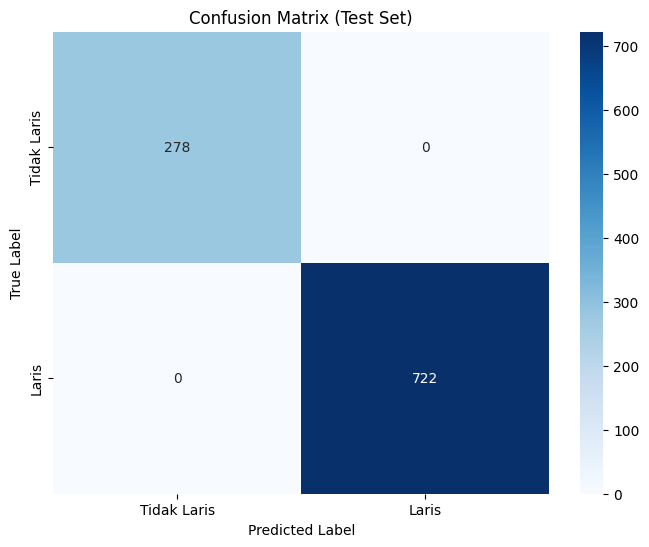

In [75]:
print('\n' + '='*60)
print('CONFUSION MATRIX VISUALIZATION')
print('='*60)

# Get the confusion matrix from the metrics dictionary
cm = metrics['confusion_matrix']

# Define class labels
class_labels = ['Tidak Laris', 'Laris']

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [73]:
def save_model(model, scaler):
    """Save model dan scaler dengan joblib"""
    print("\n" + "="*60)
    print("SAVING MODEL & SCALER")
    print("="*60)

    try:
        print(f"\nSaving model ke {MODEL_PATH}...")
        joblib.dump(model, MODEL_PATH)
        print(f"✓ Model saved successfully")
        print(f"  File size: {os.path.getsize(MODEL_PATH) / 1024:.2f} KB")

        print(f"\nSaving scaler ke {SCALER_PATH}...")
        joblib.dump(scaler, SCALER_PATH)
        print(f"✓ Scaler saved successfully")
        print(f"  File size: {os.path.getsize(SCALER_PATH) / 1024:.2f} KB")

        print("\nModel dan scaler berhasil disimpan!")
        print("Backend sekarang siap dijalankan.")

    except Exception as e:
        print(f"✗ Error saving model: {str(e)}")
        raise


# Save model
save_model(model, scaler)


SAVING MODEL & SCALER

Saving model ke model.joblib...
✓ Model saved successfully
  File size: 251.57 KB

Saving scaler ke scaler.joblib...
✓ Scaler saved successfully
  File size: 0.66 KB

Model dan scaler berhasil disimpan!
Backend sekarang siap dijalankan.
